In [55]:
import os
import json

out_dir = "../data/generated/replication/HEUN_ODE_NO_NO_REPL_POST_2001_UNCO_ep-500_sde-ve_noise-exponential_20260421_122936"

In [56]:
import json
with open(os.path.join(out_dir, "ode_heun_cmp.json"), "r") as f:
    cmp_data = json.load(f)
# cmp_data is a list of dicts with all metrics from each step


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to DataFrame for easier analysis
df = pd.DataFrame(cmp_data)
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMetrics present:\n{df.describe()}")

   step         t    upd_l1    upd_l2   upd_max  hcorr_l1  hcorr_l2  \
0     0  1.000000  0.000007  0.006576  0.000044  0.000007  0.006576   
1     1  0.999500  0.000007  0.006224  0.000034  0.000007  0.006237   
2     2  0.999000  0.000004  0.003638  0.000030  0.000004  0.003662   
3     3  0.998501  0.000003  0.002455  0.000019  0.000003  0.002482   
4     4  0.998001  0.000003  0.002238  0.000013  0.000003  0.002271   

   hcorr_max   traj_l1   traj_l2  traj_max  \
0   0.000044  0.000007  0.006576  0.000044   
1   0.000034       NaN       NaN       NaN   
2   0.000030       NaN       NaN       NaN   
3   0.000019       NaN       NaN       NaN   
4   0.000013       NaN       NaN       NaN   

                                            top_vals  \
0  [4.410743713378906e-05, 4.38690185546875e-05, ...   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4               

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   step       1999 non-null   int64  
 1   t          1999 non-null   float64
 2   upd_l1     1999 non-null   float64
 3   upd_l2     1999 non-null   float64
 4   upd_max    1999 non-null   float64
 5   hcorr_l1   1999 non-null   float64
 6   hcorr_l2   1999 non-null   float64
 7   hcorr_max  1999 non-null   float64
 8   traj_l1    100 non-null    float64
 9   traj_l2    100 non-null    float64
 10  traj_max   100 non-null    float64
 11  top_vals   100 non-null    object 
 12  top_idx    100 non-null    object 
 13  min_diff   100 non-null    float64
 14  max_diff   100 non-null    float64
 15  fd_heun    100 non-null    float64
 16  fd_ode     100 non-null    float64
dtypes: float64(14), int64(1), object(2)
memory usage: 265.6+ KB


In [59]:
df.columns

Index(['step', 't', 'upd_l1', 'upd_l2', 'upd_max', 'hcorr_l1', 'hcorr_l2',
       'hcorr_max', 'traj_l1', 'traj_l2', 'traj_max', 'top_vals', 'top_idx',
       'min_diff', 'max_diff', 'fd_heun', 'fd_ode'],
      dtype='object')

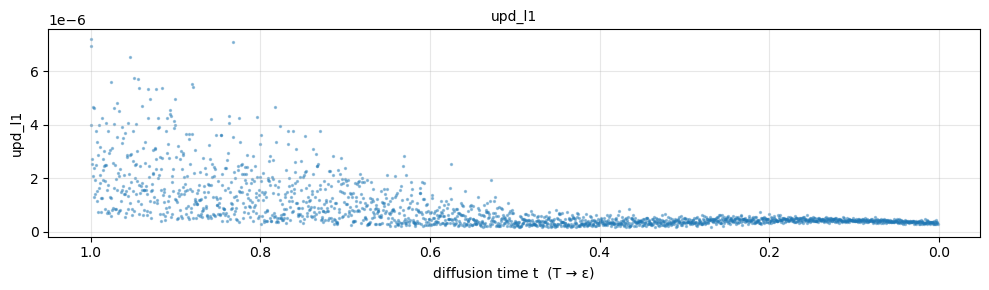

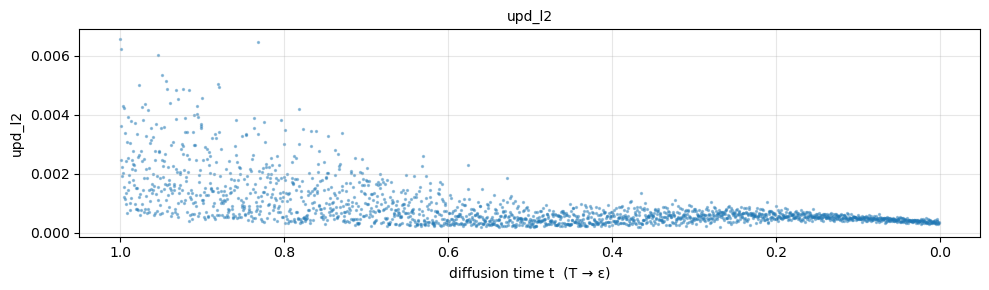

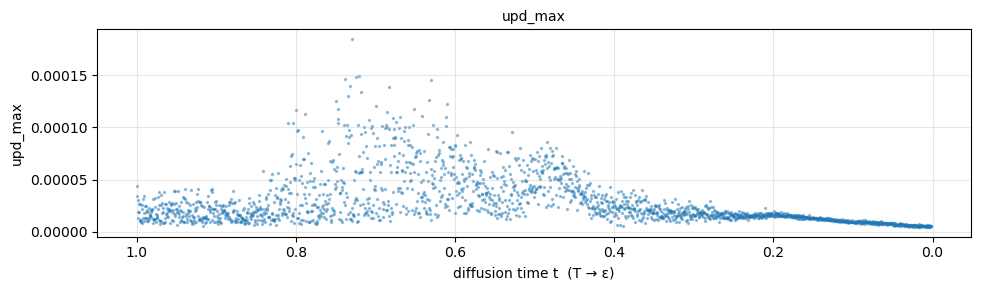

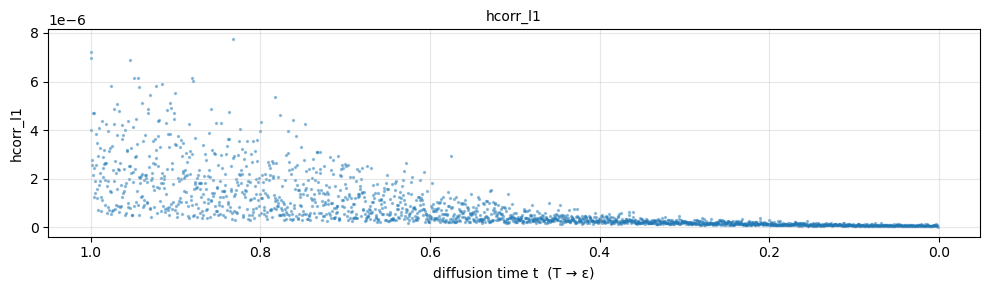

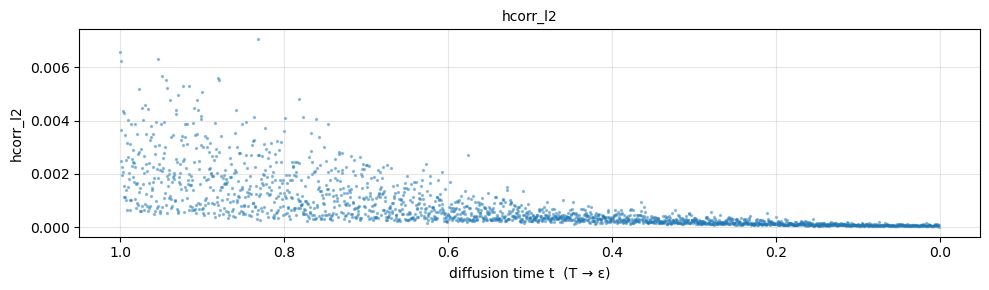

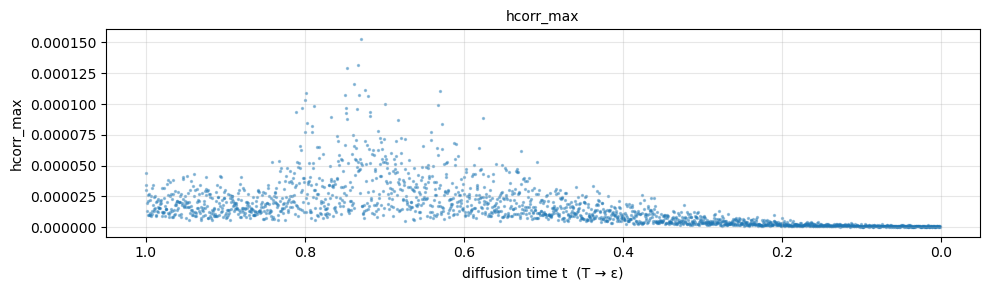

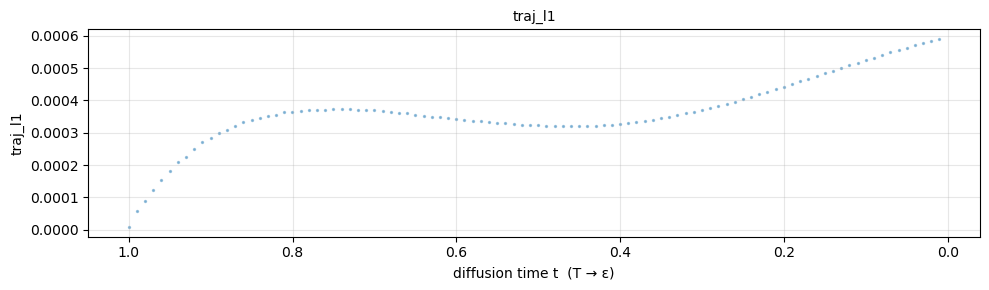

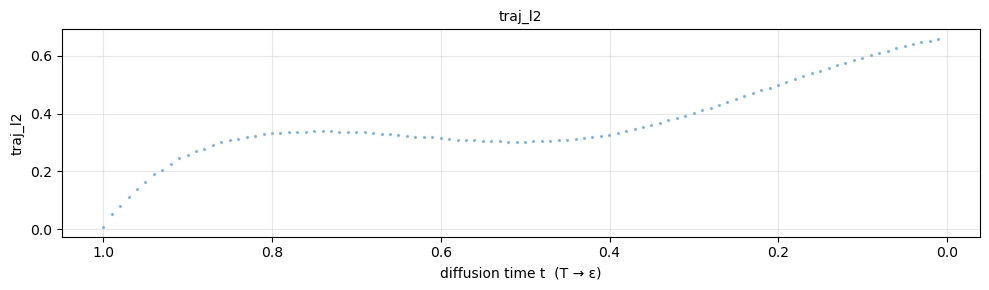

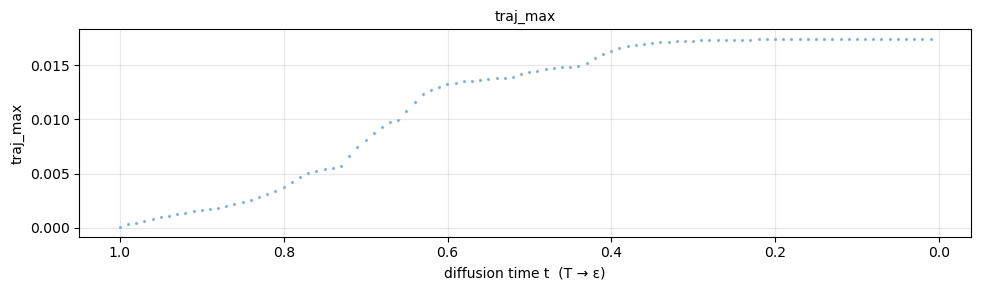

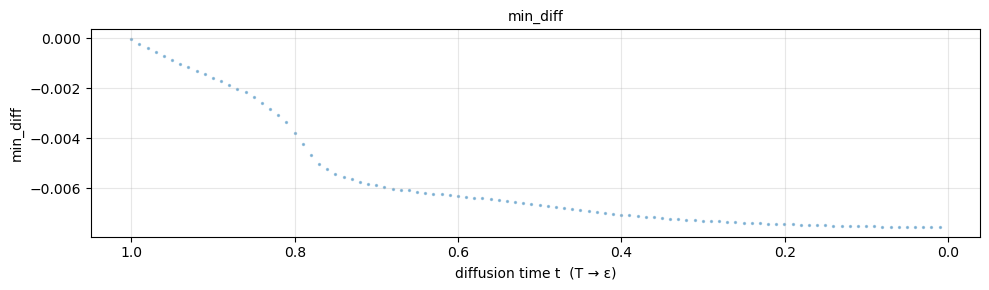

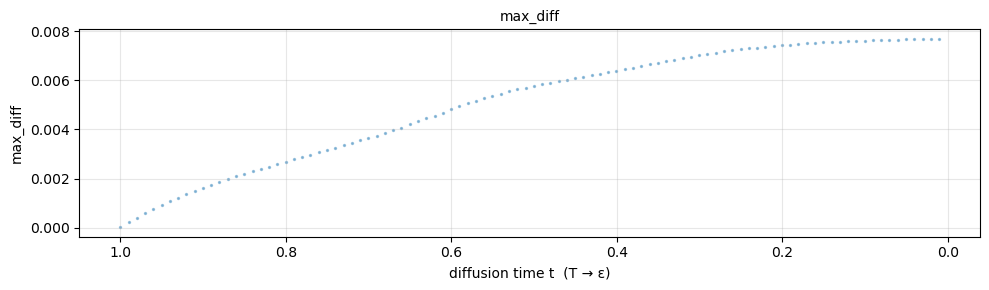

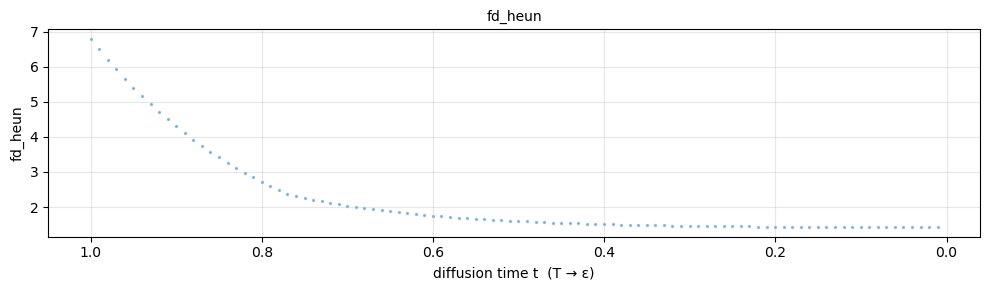

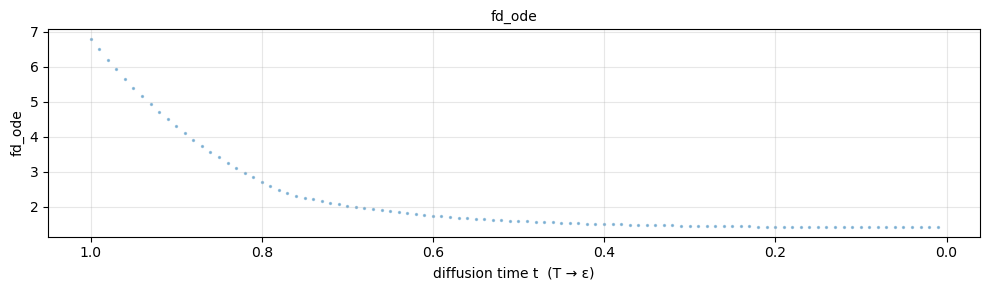

In [60]:
# Scatter plot of each numeric column vs diffusion time t — one at a time
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c not in ('step', 't')]

for col in numeric_cols:
    subset = df[['t', col]].dropna()
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.scatter(subset['t'], subset[col], s=2, alpha=0.4)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("diffusion time t  (T → ε)")
    ax.set_ylabel(col)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [61]:
print(df['traj_max'])

0       0.000044
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
1994         NaN
1995         NaN
1996         NaN
1997         NaN
1998         NaN
Name: traj_max, Length: 1999, dtype: float64


In [62]:
# Separate all-step vs checkpoint metrics
all_steps = df[df['step'].notna()].copy()
checkpoints = df[df['traj_l2'].notna()].copy()

print(f"All-step metrics: {len(all_steps)}")
print(f"Checkpoint metrics (trajectory divergence): {len(checkpoints)}")
print(f"\nMetrics always present: {all_steps.columns.tolist()}")
print(f"Metrics at checkpoints: {[c for c in checkpoints.columns if checkpoints[c].notna().sum() > 0]}")

All-step metrics: 1999
Checkpoint metrics (trajectory divergence): 100

Metrics always present: ['step', 't', 'upd_l1', 'upd_l2', 'upd_max', 'hcorr_l1', 'hcorr_l2', 'hcorr_max', 'traj_l1', 'traj_l2', 'traj_max', 'top_vals', 'top_idx', 'min_diff', 'max_diff', 'fd_heun', 'fd_ode']
Metrics at checkpoints: ['step', 't', 'upd_l1', 'upd_l2', 'upd_max', 'hcorr_l1', 'hcorr_l2', 'hcorr_max', 'traj_l1', 'traj_l2', 'traj_max', 'top_vals', 'top_idx', 'min_diff', 'max_diff', 'fd_heun', 'fd_ode']


# Graphs 1:
We are plotting:
* **Top-left**: MAE of `dx_heun - dx_ode = upd_l1` and `hcorr_l1` which is the Heun's corrector. If `upd_l1>>hcorr_l1` we should expect that the trajectories diverges.
* **Top-Right**: `upd_max`is the max absolute element-wise differnce and then we have heun's correction.
* **Bottom-left**: `traj_l1` is the MAE of (`x_heun - x_ode`) or the mean divergence between Heun's and ODE at each step. It is not cumulated.
* **Bottom-right**: this measure `fd_heun = max |x_{t+1} - x_{t}|`, and the same thing for `fd_ode`, meaning that if the value is positive then heun has a rougher update, otherwise if it is below zero is smoother.

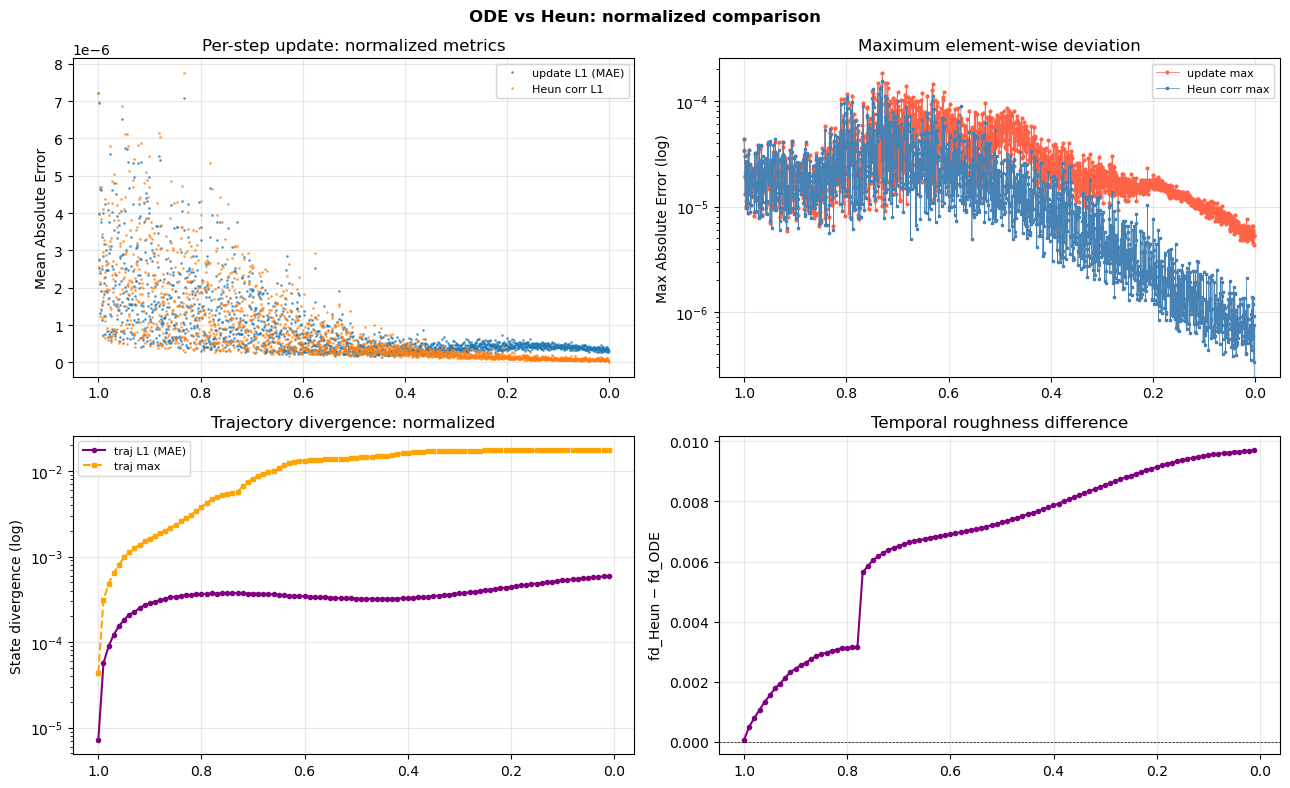

In [63]:
# === OPTION 1: Normalized metrics (scale-invariant) ===
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ax = axes[0, 0]
ax.plot(all_steps['t'], all_steps['upd_l1'], '.', ms=2, alpha=0.6, label='update L1 (MAE)')
ax.plot(all_steps['t'], all_steps['hcorr_l1'], '.', ms=2, alpha=0.6, label='Heun corr L1')
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Per-step update: normalized metrics")
ax.invert_xaxis()
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.semilogy(all_steps['t'], all_steps['upd_max'], 'o-', ms=2, color='tomato', label='update max', linewidth=0.5)
ax.semilogy(all_steps['t'], all_steps['hcorr_max'], 's-', ms=2, color='steelblue', label='Heun corr max', linewidth=0.5)
ax.set_ylabel("Max Absolute Error (log)")
ax.set_title("Maximum element-wise deviation")
ax.invert_xaxis()
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
if len(checkpoints) > 0:
    ax.semilogy(checkpoints['t'], checkpoints['traj_l1'], 'o-', ms=3, color='purple', label='traj L1 (MAE)')
    ax.semilogy(checkpoints['t'], checkpoints['traj_max'], 's--', ms=3, color='orange', label='traj max')
    ax.set_ylabel("State divergence (log)")
    ax.set_title("Trajectory divergence: normalized")
    ax.invert_xaxis()
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

ax = axes[1, 1]
if len(checkpoints) > 0 and 'fd_heun' in checkpoints.columns:
    fd_diff = np.array(checkpoints['fd_heun']) - np.array(checkpoints['fd_ode'])
    ax.plot(checkpoints['t'], fd_diff, 'o-', ms=3, color='purple')
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
    ax.set_ylabel("fd_Heun − fd_ODE")
    ax.set_title("Temporal roughness difference")
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)

plt.suptitle("ODE vs Heun: normalized comparison", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Graphs 2
It iterates among the i//k number of checkpoints and it counts across which features and sequence position, meaning the idx in the window, where such top divergences occurs. We have 100 checkpoints and we keep the top-5, therefore.
We also show across how many windows the error is actually distributed.

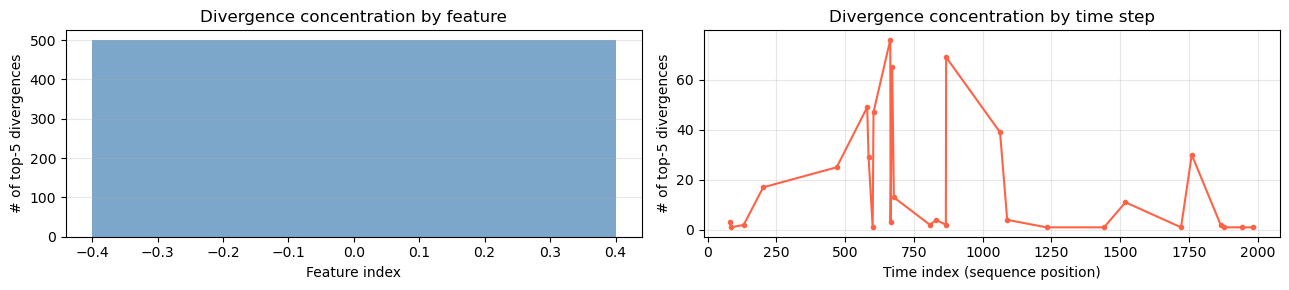

Top divergence features: [(0, 500)]
Top divergence time positions: [(664, 76), (867, 69), (671, 65), (580, 49), (603, 47)]


In [64]:
# === OPTION 2: Divergence heatmap — where does error concentrate? ===
if 'top_idx' in checkpoints.columns and len(checkpoints) > 0:
    # Extract spatial locations of top-5 divergences at each checkpoint
    divergence_hist_feat = {}  # {feature_idx: count}
    divergence_hist_time = {}  # {time_idx: count}
    
    for _, row in checkpoints.iterrows():
        if row['top_idx'] is not None:
            for b, k, l in row['top_idx']:  # batch, feature, time
                divergence_hist_feat[k] = divergence_hist_feat.get(k, 0) + 1
                divergence_hist_time[l] = divergence_hist_time.get(l, 0) + 1
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3))
    
    # Feature dimension
    if divergence_hist_feat:
        features = sorted(divergence_hist_feat.keys())
        counts = [divergence_hist_feat[f] for f in features]
        ax1.bar(features, counts, color='steelblue', alpha=0.7)
        ax1.set_xlabel("Feature index")
        ax1.set_ylabel("# of top-5 divergences")
        ax1.set_title("Divergence concentration by feature")
        ax1.grid(True, alpha=0.3, axis='y')
    
    # Time dimension
    if divergence_hist_time:
        times = sorted(divergence_hist_time.keys())
        counts = [divergence_hist_time[t] for t in times]
        ax2.plot(times, counts, 'o-', color='tomato', ms=3)
        ax2.set_xlabel("Time index (sequence position)")
        ax2.set_ylabel("# of top-5 divergences")
        ax2.set_title("Divergence concentration by time step")
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print(f"Top divergence features: {sorted(divergence_hist_feat.items(), key=lambda x: -x[1])[:5]}")
    print(f"Top divergence time positions: {sorted(divergence_hist_time.items(), key=lambda x: -x[1])[:5]}")

In [65]:
divergence_hist_batch = {}
for _, row in checkpoints.iterrows():
    if row['top_idx'] is not None:
        for b, k, l in row['top_idx']:
            divergence_hist_batch[b] = divergence_hist_batch.get(b, 0) + 1
print(sorted(divergence_hist_batch.items(), key=lambda x: -x[1]))


[(146, 78), (20, 76), (249, 69), (72, 49), (58, 47), (102, 39), (162, 32), (116, 29), (24, 25), (43, 17), (131, 12), (168, 4), (173, 4), (178, 3), (254, 3), (123, 2), (185, 2), (236, 2), (3, 1), (225, 1), (2, 1), (125, 1), (151, 1), (138, 1), (231, 1)]


# Graphs 3



=== Summary Statistics ===
                     mean       50%       max
Update L1 (MAE)  0.000001  0.000000  0.000007
Update max       0.000029  0.000019  0.000185
Heun corr L1     0.000001  0.000000  0.000008
Heun corr max    0.000016  0.000011  0.000153
Trajectory L1    0.000365  0.000356  0.000591
Trajectory max   0.011692  0.014257  0.017434
FD difference    0.006671  0.007276  0.009701


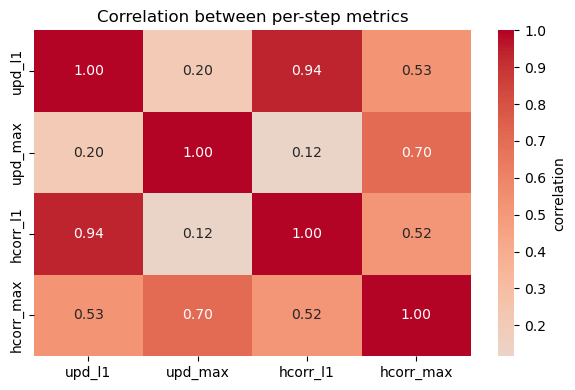

In [66]:
# === OPTION 3: Summary statistics table ===
summary_stats = {}

# Update metrics (all steps)
summary_stats['Update L1 (MAE)'] = all_steps['upd_l1'].describe()[['mean', '50%', 'max']]
summary_stats['Update max'] = all_steps['upd_max'].describe()[['mean', '50%', 'max']]
summary_stats['Heun corr L1'] = all_steps['hcorr_l1'].describe()[['mean', '50%', 'max']]
summary_stats['Heun corr max'] = all_steps['hcorr_max'].describe()[['mean', '50%', 'max']]

# Trajectory metrics (checkpoints)
if len(checkpoints) > 0:
    summary_stats['Trajectory L1'] = checkpoints['traj_l1'].describe()[['mean', '50%', 'max']]
    summary_stats['Trajectory max'] = checkpoints['traj_max'].describe()[['mean', '50%', 'max']]
    
    if 'fd_heun' in checkpoints.columns:
        fd_diff = checkpoints['fd_heun'] - checkpoints['fd_ode']
        summary_stats['FD difference'] = fd_diff.describe()[['mean', '50%', 'max']]

summary_df = pd.DataFrame(summary_stats).T
print("\n=== Summary Statistics ===")
print(summary_df.round(6))

# Correlation heatmap
if len(all_steps) > 10:
    corr_cols = ['upd_l1', 'upd_max', 'hcorr_l1', 'hcorr_max']
    if len(checkpoints) > 0:
        corr_data = all_steps[corr_cols].corr()
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'correlation'})
        ax.set_title("Correlation between per-step metrics")
        plt.tight_layout()
        plt.show()

# Graphs 5
* **Top-left**: range shifts between `min_diff` and `max_diff`.
* **Top-right**: plot `fd_heun` and `fd_ode` which represent the temporal roughness.
* **Bottom-left**: represent bar chart of traj_l1 and traj_max, but it renders only with less than 20 checkpoints
* **Bottom-right**: divergence growth rate $$\frac{\Delta |x_\text{Heun} - x_\text{ODE}|_2}{\Delta t}$$. It should be negative since t decreases and traj_l2 increases usually, therefore this has a typical negative rate. Where 0 is no change between checkpoints.

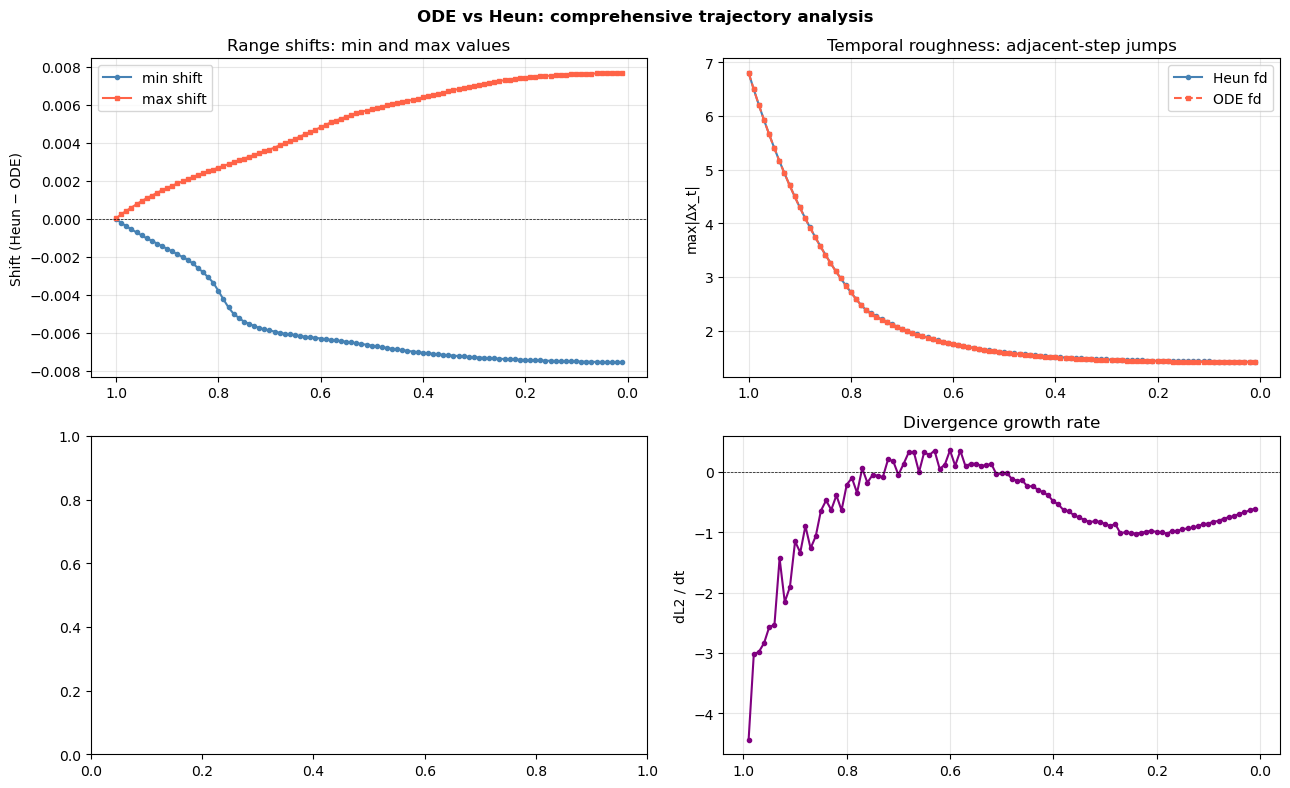

In [67]:
# === OPTION 4: Range shifts and final comparison ===
if len(checkpoints) > 0 and 'min_diff' in checkpoints.columns:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    
    # Min/max shifts
    ax = axes[0, 0]
    ax.plot(checkpoints['t'], checkpoints['min_diff'], 'o-', ms=3, color='steelblue', label='min shift')
    ax.plot(checkpoints['t'], checkpoints['max_diff'], 's-', ms=3, color='tomato', label='max shift')
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
    ax.set_ylabel("Shift (Heun − ODE)")
    ax.set_title("Range shifts: min and max values")
    ax.invert_xaxis()
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Temporal roughness
    ax = axes[0, 1]
    ax.plot(checkpoints['t'], checkpoints['fd_heun'], 'o-', ms=3, color='steelblue', label='Heun fd')
    ax.plot(checkpoints['t'], checkpoints['fd_ode'], 's--', ms=3, color='tomato', label='ODE fd')
    ax.set_ylabel("max|Δx_t|")
    ax.set_title("Temporal roughness: adjacent-step jumps")
    ax.invert_xaxis()
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Comparison of max values at checkpoints
    ax = axes[1, 0]
    metrics_to_compare = ['traj_l1', 'traj_max']
    x_pos = np.arange(len(checkpoints))
    width = 0.35
    if len(checkpoints) <= 20:
        ax.bar(x_pos - width/2, checkpoints['traj_l1'], width, label='L1 (MAE)', alpha=0.7)
        ax.bar(x_pos + width/2, checkpoints['traj_max'], width, label='max', alpha=0.7)
        ax.set_xlabel("Checkpoint")
        ax.set_ylabel("Divergence magnitude")
        ax.set_title("Trajectory divergence at each checkpoint")
        ax.legend()
    
    # Growth rate
    ax = axes[1, 1]
    if len(checkpoints) > 2:
        traj_l2_vals = checkpoints['traj_l2'].values
        growth_rate = np.diff(traj_l2_vals) / (np.diff(checkpoints['t'].values) + 1e-8)
        ax.plot(checkpoints['t'].iloc[1:], growth_rate, 'o-', ms=3, color='purple')
        ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax.set_ylabel("dL2 / dt")
        ax.set_title("Divergence growth rate")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle("ODE vs Heun: comprehensive trajectory analysis", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()